## CLIP model with Jina CLIP and OpenVINO

[jina-clip-v1](https://huggingface.co/jinaai/jina-clip-v1) is a state-of-the-art English multimodal(text-image) embedding model trained by [Jina AI](https://aimodels.fyi/creators/huggingFace/jinaai). It bridges the gap between traditional text embedding models, which excel in text-to-text retrieval but are incapable of cross-modal tasks, and models that effectively align image and text embeddings but are not optimized for text-to-text retrieval. jina-clip-v1 offers robust performance in both domains. Its dual capability makes it an excellent tool for multimodal retrieval-augmented generation (MuRAG) applications, allowing seamless text-to-text and text-to-image searches within a single model. jina-clip-v1 can be used for a variety of multimodal applications, such as: image search by describing them in text, multimodal question answering, multimodal content generation. Jina AI has also provided the Embeddings API as an easy-to-use interface for working with jina-clip-v1 and their other embedding models.

In this notebook we will load the model with Hugging Face Transformers, convert it to OpenVINO IR format, optimize it with NNCF and show the life demo for zero-shot image classification task.

## Prerequisites

In [1]:
%pip install -q "openvino>=2024.2.0" "datasets>=2.14.6" "nncf>=2.11.0"
%pip install -q --extra-index-url https://download.pytorch.org/whl/cpu "gradio>=4.19" "openvino>=2023.1.0" "transformers[torch]>=4.30" "torch>=2.1" "pillow" "einops" "timm"

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Instantiate model
[back to top ⬆️](#Table-of-contents:)


Let's load the [jinaai/jina-clip-v1](https://huggingface.co/jinaai/jina-clip-v1) with Hugging Face Transformers. We creates PyTorch model class instance with `AutoModel`, load and initialize it with model configuration and weights, using `from_pretrained` method.

In [2]:
from transformers import AutoModel

model = AutoModel.from_pretrained("jinaai/jina-clip-v1", trust_remote_code=True)

### Prepare input data
[back to top ⬆️](#Table-of-contents:)

The model can encode meaningful sentences in English as text input. Image could be provided to model as local file path, URLs or directly passing in the PIL.Image objects.

In [3]:
from PIL import Image
import requests

# image input data
r = requests.get(
    url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
)

open("notebook_utils.py", "w").write(r.text)
from notebook_utils import download_file

download_file(
    "https://github.com/openvinotoolkit/openvino_notebooks/assets/29454499/3f779fc1-c1b2-4dec-915a-64dae510a2bb",
    "furseal.png",
    directory="data",
)

img_furseal = Image.open("./data/furseal.png")

image_path = download_file(
    "https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/image/coco.jpg",
    directory="data",
)

img_coco = Image.open("./data/coco.jpg")

IMAGE_INPUTS = [img_furseal, img_coco]

# text input data
TEXT_INPUTS = ["Seal", "Cobra", "Rat", "Penguin", "Dog"]

data/furseal.png:   0%|          | 0.00/2.55M [00:00<?, ?B/s]

data/coco.jpg:   0%|          | 0.00/202k [00:00<?, ?B/s]

In [4]:
from typing import List
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


def visualize_result(image: Image, labels: List[str], probs: np.ndarray, top: int = 5):
    """
    Utility function for visualization classification results
    params:
      image: input image
      labels: list of classification labels
      probs: model predicted softmaxed probabilities for each label
      top: number of the highest probability results for visualization
    returns:
      None
    """
    plt.figure(figsize=(64, 64))
    top_labels = np.argsort(-probs)[: min(top, probs.shape[0])]
    top_probs = probs[top_labels]
    plt.subplot(8, 8, 1)
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(8, 8, 2)
    y = np.arange(top_probs.shape[-1])
    plt.grid()
    plt.barh(y, top_probs)
    plt.gca().invert_yaxis()
    plt.gca().set_axisbelow(True)
    plt.yticks(y, [labels[index] for index in top_labels])
    plt.xlabel("probability")

### Run PyTorch model inference

We can get text embeddings or/and image embeddings separately and calculate similarity by themselves.

In [5]:
text_embeddings = model.encode_text(TEXT_INPUTS)
image_embeddings = model.encode_image(IMAGE_INPUTS)


def print_similarity(indx_img_emb):
    for i, text_emb in enumerate(text_embeddings):
        print(f"{TEXT_INPUTS[i]} {text_emb @ image_embeddings[indx_img_emb]}")


print("Seal image: ")
print_similarity(0)

print("\nCoco image: ")
print_similarity(1)

Seal image: 
Seal 0.22464095056056976
Cobra 0.011074207723140717
Rat 0.012166828848421574
Penguin 0.12132224440574646
Dog 0.06303957849740982

Coco image: 
Seal 0.07889220118522644
Cobra 0.07213523983955383
Rat 0.02007526159286499
Penguin -0.015811659395694733
Dog 0.13050368428230286


But also if you are interested in text-to-image task, we can get tokenizer for text inputs and processor for image inputs, encode inputs and put it to model. Then we will have text embeddings, image embeddings and similarity scores(the model can compute the cosine similarity between text and image embeddings)

In [6]:
from transformers import TensorType

tokenizer = model.get_tokenizer()

tokenizer_kwargs = dict()
tokenizer_kwargs["padding"] = "max_length"
tokenizer_kwargs["max_length"] = 512
tokenizer_kwargs["truncation"] = True

text_inputs = tokenizer(
    TEXT_INPUTS,
    return_tensors="pt",
    **tokenizer_kwargs,
).to("cpu")

text_inputs = text_inputs.convert_to_tensors(TensorType.PYTORCH)

processor = model.get_preprocess()
visual_inputs = processor(images=IMAGE_INPUTS)
visual_inputs = visual_inputs.convert_to_tensors(TensorType.PYTORCH)

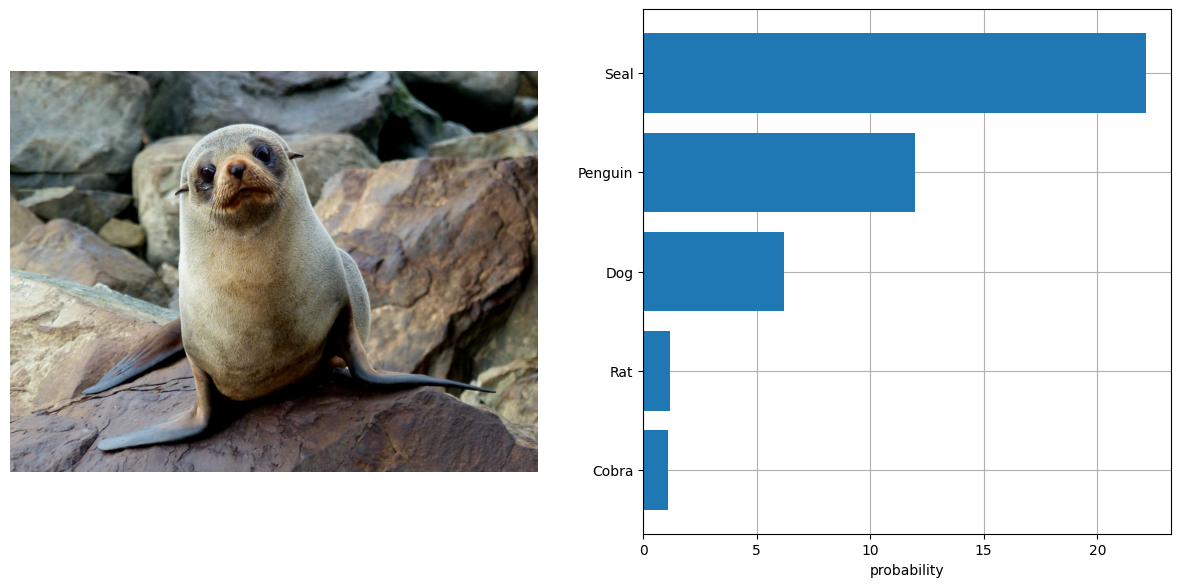

In [7]:
result = model(text_inputs["input_ids"], visual_inputs["pixel_values"])

visualize_result(IMAGE_INPUTS[0], TEXT_INPUTS, result["logits_per_image"][0].detach().numpy())

## Run OpenVINO model inference
[back to top ⬆️](#Table-of-contents:)

We convert CLIP model to OpenVINO IR format. But it is also possible to convert the text and visual part separately, for this it is needed to get the text model with `model.text_model`, visual model `model.visual_model` and call `ov.convert_model` for both model with corresponding `example_input`.

### Convert Model to OpenVINO IR format
[back to top ⬆️](#Table-of-contents:)

OpenVINO supports PyTorch models via conversion to OpenVINO Intermediate Representation (IR). OpenVINO model conversion API should be used for these purposes. `ov.convert_model` function accepts original PyTorch model instance and example input for tracing and returns `ov.Model` representing this model in OpenVINO framework. Converted model can be used for saving on disk using `ov.save_model` function or directly loading on device using `core.complie_model`.

In [8]:
import openvino as ov
from pathlib import Path

core = ov.Core()

fp16_model_path = Path("jina-clip-v1_fp16.xml")
TEXT_IMAGE_INPUTS = {"pixel_values": visual_inputs["pixel_values"], "input_ids": text_inputs["input_ids"]}

if not fp16_model_path.exists():
    ov_model = ov.convert_model(model, example_input=TEXT_IMAGE_INPUTS)
    ov.save_model(ov_model, fp16_model_path)

/home/labuser/work/notebook/jina/lib/python3.10/site-packages/transformers/modeling_utils.py:4565: FutureWarning: `_is_quantized_training_enabled` is going to be deprecated in transformers 4.39.0. Please use `model.hf_quantizer.is_trainable` instead
  warnings.warn(
/home/labuser/.cache/huggingface/modules/transformers_modules/jinaai/jina-clip-implementation/952897b38094b9f6a47b3d9a1d8239523e374098/eva_model.py:468: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert H == self.img_size[0] and W == self.img_size[1], (
/home/labuser/.cache/huggingface/modules/transformers_modules/jinaai/jina-bert-flash-implementation/b78d1595de294f13ffe7b19d6cd63892a6e4e7a4/mha.py:333: TracerWarning: Converting a tensor to a Python float might cause the trace to be incorrect. We can't r

### Select inference device
[back to top ⬆️](#Table-of-contents:)

For starting work, please select inference device from dropdown list.

In [9]:
import ipywidgets as widgets

device = widgets.Dropdown(
    options=core.available_devices + ["AUTO"],
    value="AUTO",
    description="Device:",
    disabled=False,
)

device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

### Compile model and run inference

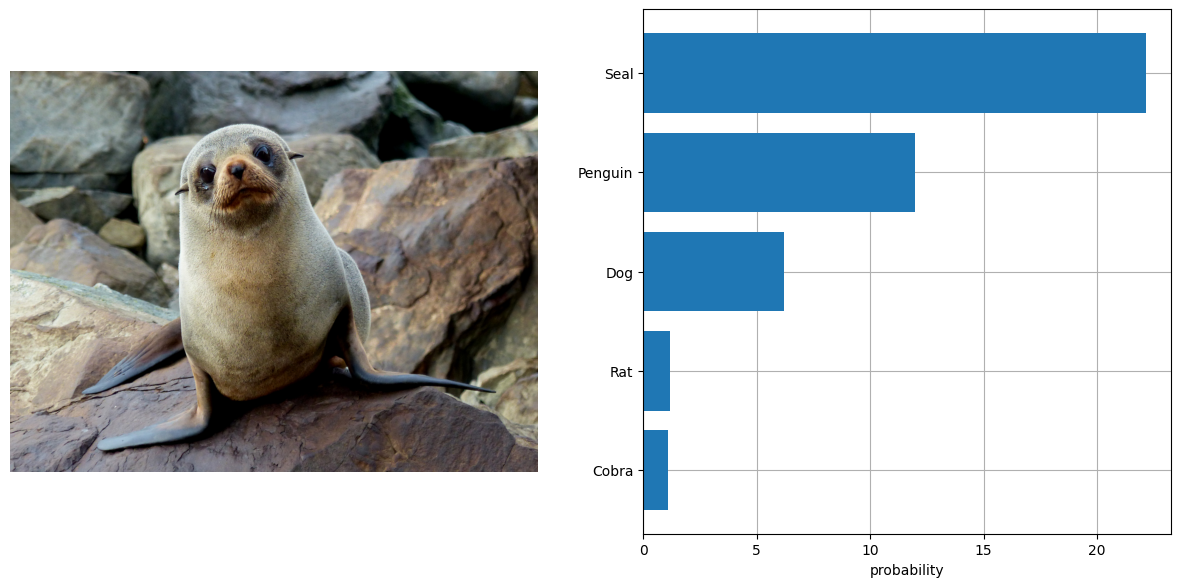

In [10]:
compiled_model = core.compile_model(fp16_model_path, device.value)

res_ov = compiled_model(TEXT_IMAGE_INPUTS)
visualize_result(IMAGE_INPUTS[0], TEXT_INPUTS, res_ov["logits_per_image"][0])

## Quantize model to INT8 using NNCF
[back to top ⬆️](#Table-of-contents:)


Lets speed up the model by applying 8-bit post-training quantization from [NNCF](https://github.com/openvinotoolkit/nncf/) (Neural Network Compression Framework) and infer quantized model via OpenVINO™ Toolkit. 
[NNCF](https://github.com/openvinotoolkit/nncf/) enables post-training quantization by adding quantization layers into model graph and then using a subset of the training dataset to initialize the parameters of these additional quantization layers. Quantized operations are executed in `INT8` instead of `FP32`/`FP16` making model inference faster.
The optimization process contains the following steps:

1. Prepare quantization dataset
2. Quantize the converted OpenVINO model with NNCF with `nncf.quantize()`.
3. Save the `INT8` model using `openvino.save_model()` function.
4. Compare model size of converted and quantized models.
5. Compare performance of converted and quantized models.

> **Note:** quantization process may require additional time and memory for performing. You can disable it using widget below:

In [11]:
to_quantize = widgets.Checkbox(
    value=True,
    description="Quantization",
    disabled=False,
)

to_quantize

Checkbox(value=True, description='Quantization')

In [12]:
# Fetch `skip_kernel_extension` module
r = requests.get(
    url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/skip_kernel_extension.py",
)
open("skip_kernel_extension.py", "w").write(r.text)

%load_ext skip_kernel_extension

### Prepare datasets
[back to top ⬆️](#Table-of-contents:)

The [Conceptual Captions](https://ai.google.com/research/ConceptualCaptions/) dataset consisting of ~3.3M images annotated with captions is used to quantize model.

In [13]:
%%skip not $to_quantize.value

import requests
from io import BytesIO
import numpy as np
from PIL import Image
from requests.packages.urllib3.exceptions import InsecureRequestWarning
requests.packages.urllib3.disable_warnings(InsecureRequestWarning)

def check_text_data(data):
    """
    Check if the given data is text-based.
    """
    if isinstance(data, str):
        return True
    if isinstance(data, list):
        return all(isinstance(x, str) for x in data)
    return False

def get_pil_from_url(url):
    """
    Downloads and converts an image from a URL to a PIL Image object.
    """
    response = requests.get(url, verify=False, timeout=20)
    image = Image.open(BytesIO(response.content))
    # return image.convert("RGB")
    return image.resize((600, 400))

def collate_fn(example, image_column="image_url", text_column="caption"):
    """
    Preprocesses an example by loading and transforming image and text data.
    Checks if the text data in the example is valid by calling the `check_text_data` function.
    Downloads the image specified by the URL in the image_column by calling the `get_pil_from_url` function.
    If there is any error during the download process, returns None.
    Returns the preprocessed inputs with transformed image and text data.
    """
    assert len(example) == 1
    example = example[0]

    if not check_text_data(example[text_column]):
        raise ValueError("Text data is not valid")

    url = example[image_column]
    try:
        image = get_pil_from_url(url)
        h, w = image.size
        if h == 1 or w == 1:
            return None
    except Exception:
        return None

    visual_input = processor(images=[image])
    text_input = tokenizer(
        example[text_column],
        return_tensors='pt',
        **tokenizer_kwargs)

    inputs = {"pixel_values": visual_input.pixel_values, "input_ids": text_input.input_ids}
    if inputs['input_ids'].shape[1] > 512:
        return None
    return inputs

In [14]:
%%skip not $to_quantize.value

import torch
from datasets import load_dataset
from tqdm.notebook import tqdm

def prepare_calibration_data(dataloader, init_steps):
    """
    This function prepares calibration data from a dataloader for a specified number of initialization steps.
    It iterates over the dataloader, fetching batches and storing the relevant data.
    """
    data = []
    print(f"Fetching {init_steps} samples for the initialization...")
    with tqdm(total=init_steps) as pbar:
        for batch in dataloader:
            if len(data) == init_steps:
                break
            if batch:
                pbar.update(1)
                with torch.no_grad():
                    data.append(
                        {
                            "pixel_values": batch["pixel_values"].to("cpu"),
                            "input_ids": batch["input_ids"].to("cpu")
                        }
                    )
    return data


def prepare_dataset(opt_init_steps=50, max_train_samples=1000):
    """
    Prepares a vision-text dataset for quantization.
    """
    dataset = load_dataset("google-research-datasets/conceptual_captions", trust_remote_code=True)
    train_dataset = dataset["train"].shuffle(seed=42)
    dataloader = torch.utils.data.DataLoader(train_dataset, collate_fn=collate_fn, batch_size=1)
    calibration_data = prepare_calibration_data(dataloader, opt_init_steps)
    return calibration_data

In [15]:
%%skip not $to_quantize.value

import logging
import nncf

core = ov.Core()

nncf.set_log_level(logging.ERROR)

calibration_data = prepare_dataset()
ov_model = core.read_model(fp16_model_path)

INFO:nncf:NNCF initialized successfully. Supported frameworks detected: torch, openvino
Fetching 50 samples for the initialization...


  0%|          | 0/50 [00:00<?, ?it/s]

### Perform quantization
[back to top ⬆️](#Table-of-contents:)

Create a quantized model from the pre-trained `FP16` model.

> **NOTE**: Quantization is time and memory consuming operation. Running quantization code below may take a long time.

In [ ]:
%%skip not $to_quantize.value

if len(calibration_data) == 0:
    raise RuntimeError(
        'Calibration dataset is empty. Please check internet connection and try to download images manually.'
    )

int8_model_path = 'jina-clip-v1_int8.xml'
calibration_dataset = nncf.Dataset(calibration_data)
quantized_model = nncf.quantize(
    model=ov_model,
    calibration_dataset=calibration_dataset
)
ov.save_model(quantized_model, int8_model_path)

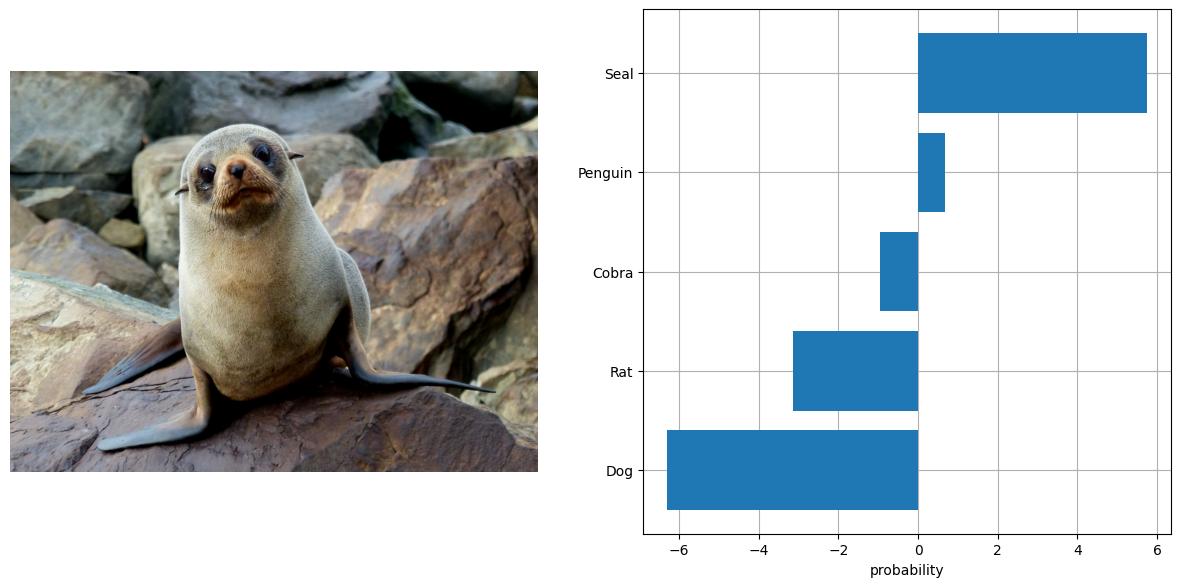

In [17]:
%%skip not $to_quantize.value

compiled_model_int8 = core.compile_model(quantized_model, device.value)
int8_res_ov = compiled_model_int8(TEXT_IMAGE_INPUTS)
visualize_result(IMAGE_INPUTS[0], TEXT_INPUTS, int8_res_ov['logits_per_image'][0])

### Compare File Size
[back to top ⬆️](#Table-of-contents:)

In [18]:
from pathlib import Path

fp16_ir_model_size = Path(fp16_model_path).with_suffix(".bin").stat().st_size / 1024 / 1024
quantized_model_size = Path(int8_model_path).with_suffix(".bin").stat().st_size / 1024 / 1024
print(f"FP16 IR model size: {fp16_ir_model_size:.2f} MB")
print(f"INT8 model size: {quantized_model_size:.2f} MB")
print(f"Model compression rate: {fp16_ir_model_size / quantized_model_size:.3f}")

FP16 IR model size: 430.71 MB
INT8 model size: 219.62 MB
Model compression rate: 1.961


### Compare inference time of the FP16 IR and quantized models
[back to top ⬆️](#Table-of-contents:)
To measure the inference performance of the `FP16` and `INT8` models, we use median inference time on calibration dataset.
So we can approximately estimate the speed up of the dynamic quantized models.


> **NOTE**: For the most accurate performance estimation, it is recommended to run `benchmark_app` in a terminal/command prompt after closing other applications with static shapes.

In [19]:
import time


def calculate_inference_time(model_path, calibration_data):
    model = core.compile_model(model_path, device.value)
    inference_time = []
    for batch in calibration_data:
        start = time.perf_counter()
        _ = model(batch)[0]
        end = time.perf_counter()
        delta = end - start
        inference_time.append(delta)
    return np.median(inference_time)

In [20]:
fp16_latency = calculate_inference_time(fp16_model_path, calibration_data)
int8_latency = calculate_inference_time(int8_model_path, calibration_data)
print(f"Performance speed up: {fp16_latency / int8_latency:.3f}")

Performance speed up: 1.578


## Gradio demo

You can provide your own image and comma-separated list of labels for zero-shot classification.

Feel free to upload an image, using the file upload window and type label names into the text field, using comma as the separator (for example, `cat,dog,bird`)

In [ ]:
import gradio as gr


def classify(image, text):
    """Classify image using classes listing.
    Args:
        image (np.ndarray): image that needs to be classified in CHW format.
        text (str): comma-separated list of class labels
    Returns:
        (dict): Mapping between class labels and class probabilities.
    """
    labels = text.split(",")
    visual_input = processor(images=[image])

    text_descriptions = [f"This is photo of a {label}" for label in labels]
    text_inputs = tokenizer(text_descriptions, return_tensors="pt", **tokenizer_kwargs)

    res = compiled_model({"pixel_values": visual_input["pixel_values"], "input_ids": text_inputs["input_ids"]})
    probs = res["logits_per_image"][0]

    return {label: float(prob / 100) for label, prob in zip(labels, probs)}


demo = gr.Interface(
    classify,
    [
        gr.Image(label="Image", type="pil"),
        gr.Textbox(label="Labels", info="Comma-separated list of class labels"),
    ],
    gr.Label(label="Result"),
    examples=[[img_furseal, "seal,dog,bird"]],
)
try:
    demo.launch(debug=True)
except Exception:
    demo.launch(share=True, debug=True)
# if you are launching remotely, specify server_name and server_port
# demo.launch(server_name='your server name', server_port='server port in int')
# Read more in the docs: https://gradio.app/docs/